In [1]:
print("Hello NHL Analytics")


Hello NHL Analytics


In [2]:
import requests
import pandas as pd
import json

def get_game_ids(season):
    """Get all game IDs for a given season"""
    url = f"https://api-web.nhle.com/v1/schedule/now"
    
    # Use the schedule endpoint to get games
    season_url = f"https://api-web.nhle.com/v1/club-schedule-season/TOR/{season}"
    response = requests.get(season_url)
    print(f"Status code: {response.status_code}")
    print(f"Response preview: {str(response.json())[:500]}")
    return response.json()

# Test the API connection with the current season
result = get_game_ids("20232024")

/Users/ashgarg/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Status code: 200
Response preview: {'previousSeason': 20222023, 'currentSeason': 20232024, 'nextSeason': 20242025, 'clubTimezone': 'America/Toronto', 'clubUTCOffset': '-04:00', 'games': [{'id': 2023010007, 'season': 20232024, 'gameType': 1, 'gameDate': '2023-09-24', 'venue': {'default': 'Canadian Tire Centre', 'fr': 'Centre Canadian Tire'}, 'neutralSite': False, 'startTimeUTC': '2023-09-24T18:00:00Z', 'easternUTCOffset': '-04:00', 'venueUTCOffset': '-04:00', 'venueTimezone': 'US/Eastern', 'gameState': 'FINAL', 'gameScheduleState'


In [3]:
def get_game_plays(game_id):
    """Get all plays/events from a specific game"""
    url = f"https://api-web.nhle.com/v1/gamecenter/{game_id}/play-by-play"
    response = requests.get(url)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}")
        return None

def extract_shots(game_data):
    """Extract all shots from game data"""
    shots = []
    
    if not game_data:
        return shots
    
    # Get home and away team info
    home_team = game_data.get('homeTeam', {})
    away_team = game_data.get('awayTeam', {})
    
    # Get all plays
    plays = game_data.get('plays', [])
    
    for play in plays:
        # We want shots on goal and goals
        type_code = play.get('typeCode')
        
        # Type code 505 is goal, 506 is shot on goal
        if type_code in [505, 506]:
            details = play.get('details', {})
            
            shot = {
                'game_id': game_data.get('id'),
                'period': play.get('periodDescriptor', {}).get('number'),
                'time': play.get('timeInPeriod'),
                'shot_type': details.get('shotType'),
                'shooting_player_id': details.get('shootingPlayerId'),
                'goalie_id': details.get('goalieInNetId'),
                'x_coord': details.get('xCoord'),
                'y_coord': details.get('yCoord'),
                'zone': details.get('zoneCode'),
                'is_goal': 1 if type_code == 505 else 0,
                'home_team': home_team.get('abbrev'),
                'away_team': away_team.get('abbrev'),
                'event_team': details.get('eventOwnerTeamId')
            }
            shots.append(shot)
    
    return shots

# Test with a real game - this is game 1 of the 2023-2024 regular season
test_game_id = 2023020001
game_data = get_game_plays(test_game_id)

if game_data:
    shots = extract_shots(game_data)
    shots_df = pd.DataFrame(shots)
    print(f"Successfully extracted {len(shots)} shots")
    print("\nFirst few shots:")
    print(shots_df.head(10))
    print("\nShot types found:")
    print(shots_df['shot_type'].value_counts())
    

Successfully extracted 65 shots

First few shots:
      game_id  period   time shot_type  shooting_player_id  goalie_id  \
0  2023020001       1  01:01     wrist           8478178.0  8477424.0   
1  2023020001       1  01:10    tip-in           8478010.0  8477424.0   
2  2023020001       1  01:47      snap           8479661.0  8477424.0   
3  2023020001       1  02:57     wrist           8479591.0  8477424.0   
4  2023020001       1  07:15      snap           8478508.0  8477992.0   
5  2023020001       1  08:26      snap           8480748.0  8477992.0   
6  2023020001       1  09:24     wrist           8475167.0  8477424.0   
7  2023020001       1  09:48      slap                 NaN  8477424.0   
8  2023020001       1  10:15      snap           8478416.0  8477424.0   
9  2023020001       1  10:37     wrist           8476822.0  8477424.0   

   x_coord  y_coord zone  is_goal home_team away_team  event_team  
0       58      -25    O        0       TBL       NSH          14  
1       81

In [4]:
def find_player(name):
    """Search for a player by name in the NHL API"""
    search_name = name.replace(" ", "%20")
    url = f"https://api-web.nhle.com/v1/search/player?q={search_name}&culture=en-us&limit=5"
    response = requests.get(url)
    if response.status_code == 200:
        results = response.json()
        for player in results:
            print(f"Name: {player.get('name')}")
            print(f"ID: {player.get('playerId')}")
            print(f"Team: {player.get('teamAbbrev')}")
            print(f"Position: {player.get('positionCode')}")
            print("---")
    return response.json()

results = find_player("Kuemper")

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [5]:
def find_player_v2(last_name):
    """Search for player using stats endpoint"""
    url = f"https://api-web.nhle.com/v1/skater-stats-leaders/20242025/2?categories=goals&limit=100"
    
    # Try the roster approach instead - get LA Kings roster
    roster_url = "https://api-web.nhle.com/v1/roster/LAK/20242025"
    response = requests.get(roster_url)
    
    if response.status_code == 200:
        data = response.json()
        # Look through goalies
        goalies = data.get('goalies', [])
        print(f"Found {len(goalies)} goalies on LA Kings roster")
        for goalie in goalies:
            print(f"Name: {goalie.get('firstName', {}).get('default')} {goalie.get('lastName', {}).get('default')}")
            print(f"ID: {goalie.get('id')}")
            print("---")
    else:
        print(f"Error: {response.status_code}")

find_player_v2("Kuemper")

Found 4 goalies on LA Kings roster
Name: Pheonix Copley
ID: 8477831
---
Name: Carter George
ID: 8484857
---
Name: Darcy Kuemper
ID: 8475311
---
Name: David Rittich
ID: 8479496
---


In [6]:
def get_goalie_game_log(player_id, season):
    """Get every game a goalie played in a season"""
    url = f"https://api-web.nhle.com/v1/player/{player_id}/game-log/{season}/2"
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        games = data.get('gameLog', [])
        print(f"Found {len(games)} games for season {season}")
        for game in games[:5]:
            print(f"Game ID: {game.get('gameId')} | Date: {game.get('gameDate')} | Home/Away: {game.get('homeRoadFlag')} | Decision: {game.get('decision')}")
        return games
    else:
        print(f"Error: {response.status_code}")
        return []

# Get his game log for both seasons
games_2425 = get_goalie_game_log(8475311, "20242025")
print("---")
games_2324 = get_goalie_game_log(8475311, "20232024")


Found 50 games for season 20242025
Game ID: 2024021289 | Date: 2025-04-14 | Home/Away: R | Decision: W
Game ID: 2024021267 | Date: 2025-04-12 | Home/Away: H | Decision: W
Game ID: 2024021259 | Date: 2025-04-10 | Home/Away: H | Decision: W
Game ID: 2024021233 | Date: 2025-04-07 | Home/Away: H | Decision: L
Game ID: 2024021213 | Date: 2025-04-05 | Home/Away: H | Decision: W
---
Found 33 games for season 20232024
Game ID: 2023021212 | Date: 2024-04-05 | Home/Away: R | Decision: L
Game ID: 2023021189 | Date: 2024-04-02 | Home/Away: R | Decision: None
Game ID: 2023021109 | Date: 2024-03-22 | Home/Away: H | Decision: None
Game ID: 2023021043 | Date: 2024-03-13 | Home/Away: R | Decision: L
Game ID: 2023020923 | Date: 2024-02-26 | Home/Away: H | Decision: W


In [7]:
games_2526 = get_goalie_game_log(8475311, "20252026")

Found 49 games for season 20252026
Game ID: 2025021217 | Date: 2026-04-04 | Home/Away: H | Decision: W
Game ID: 2025021204 | Date: 2026-04-02 | Home/Away: H | Decision: O
Game ID: 2025021164 | Date: 2026-03-28 | Home/Away: H | Decision: L
Game ID: 2025021149 | Date: 2026-03-26 | Home/Away: R | Decision: W
Game ID: 2025021133 | Date: 2026-03-24 | Home/Away: R | Decision: O


In [8]:
print(f"Games in 2025-2026: {len(games_2526)}")
print(f"Games in 2024-2025: {len(games_2425)}")
print(f"Games in 2023-2024: {len(games_2324)}")
print(f"Total games: {len(games_2526) + len(games_2425) + len(games_2324)}")

Games in 2025-2026: 49
Games in 2024-2025: 50
Games in 2023-2024: 33
Total games: 132


In [9]:
# Combine all three seasons game logs
all_kuemper_games = games_2526 + games_2425 + games_2324

print(f"Total games to process: {len(all_kuemper_games)}")

# Pull all shots across all three seasons
print("\nStarting shot data pull for all 132 games...")
print("This will take approximately 7-8 minutes...")
print("You will see progress every 10 games\n")

shots_all = get_kuemper_shots(all_kuemper_games)

# Convert to dataframe
kuemper_df = pd.DataFrame(shots_all)

# Save to CSV
kuemper_df.to_csv('kuemper_shots_all_seasons.csv', index=False)

print(f"\nAll done!")
print(f"Total shots collected: {len(shots_all)}")
print(f"Saved to kuemper_shots_all_seasons.csv")
print("\nQuick summary:")
print(f"Goals allowed: {kuemper_df['is_goal'].sum()}")
print(f"Saves: {len(kuemper_df) - kuemper_df['is_goal'].sum()}")
print(f"Overall save percentage: {1 - kuemper_df['is_goal'].mean():.3f}")
print("\nShots by type:")
print(kuemper_df['shot_type'].value_counts())
print("\nGoals by shot type:")
print(kuemper_df.groupby('shot_type')['is_goal'].sum().sort_values(ascending=False))

Total games to process: 132

Starting shot data pull for all 132 games...
This will take approximately 7-8 minutes...
You will see progress every 10 games



NameError: name 'get_kuemper_shots' is not defined

In [10]:
def get_kuemper_shots(games_list, kuemper_id=8475311):
    """Extract all shots faced by Kuemper from his game list"""
    all_shots = []
    total_games = len(games_list)
    
    for i, game in enumerate(games_list):
        game_id = game.get('gameId')
        game_date = game.get('gameDate')
        
        url = f"https://api-web.nhle.com/v1/gamecenter/{game_id}/play-by-play"
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            game_data = response.json()
            plays = game_data.get('plays', [])
            
            for play in plays:
                type_code = play.get('typeCode')
                
                if type_code in [505, 506]:
                    details = play.get('details', {})
                    goalie_in_net = details.get('goalieInNetId')
                    
                    if goalie_in_net == kuemper_id:
                        shot = {
                            'game_id': game_id,
                            'game_date': game_date,
                            'period': play.get('periodDescriptor', {}).get('number'),
                            'time': play.get('timeInPeriod'),
                            'shot_type': details.get('shotType'),
                            'shooting_player_id': details.get('shootingPlayerId'),
                            'x_coord': details.get('xCoord'),
                            'y_coord': details.get('yCoord'),
                            'zone': details.get('zoneCode'),
                            'is_goal': 1 if type_code == 505 else 0,
                            'situation_code': play.get('situationCode')
                        }
                        all_shots.append(shot)
        
        if (i + 1) % 10 == 0:
            print(f"Progress: {i+1}/{total_games} games processed | {len(all_shots)} shots collected so far")
        
        time.sleep(0.3)
    
    print(f"\nCompleted! Total shots collected: {len(all_shots)}")
    return all_shots


In [11]:
# Combine all three seasons game logs
all_kuemper_games = games_2526 + games_2425 + games_2324

print(f"Total games to process: {len(all_kuemper_games)}")

print("\nStarting shot data pull for all 132 games...")
print("This will take approximately 7-8 minutes...")
print("You will see progress every 10 games\n")

shots_all = get_kuemper_shots(all_kuemper_games)

kuemper_df = pd.DataFrame(shots_all)

kuemper_df.to_csv('kuemper_shots_all_seasons.csv', index=False)

print(f"\nAll done!")
print(f"Total shots collected: {len(shots_all)}")
print(f"Saved to kuemper_shots_all_seasons.csv")
print(f"Overall save percentage: {1 - kuemper_df['is_goal'].mean():.3f}")
print("\nShots by type:")
print(kuemper_df['shot_type'].value_counts())
print("\nGoals by shot type:")
print(kuemper_df.groupby('shot_type')['is_goal'].sum().sort_values(ascending=False))

Total games to process: 132

Starting shot data pull for all 132 games...
This will take approximately 7-8 minutes...
You will see progress every 10 games



NameError: name 'time' is not defined

In [12]:
import requests
import pandas as pd
import json
import time

In [13]:
# Combine all three seasons game logs
all_kuemper_games = games_2526 + games_2425 + games_2324

print(f"Total games to process: {len(all_kuemper_games)}")

print("\nStarting shot data pull for all 132 games...")
print("This will take approximately 7-8 minutes...")
print("You will see progress every 10 games\n")

shots_all = get_kuemper_shots(all_kuemper_games)

kuemper_df = pd.DataFrame(shots_all)

kuemper_df.to_csv('kuemper_shots_all_seasons.csv', index=False)

print(f"\nAll done!")
print(f"Total shots collected: {len(shots_all)}")
print(f"Saved to kuemper_shots_all_seasons.c

SyntaxError: EOL while scanning string literal (3126348823.py, line 18)

In [14]:
# Combine all three seasons
all_kuemper_games = games_2526 + games_2425 + games_2324
print("Total games:", len(all_kuemper_games))

# Pull all shots
shots_all = get_kuemper_shots(all_kuemper_games)

# Convert to dataframe
kuemper_df = pd.DataFrame(shots_all)

# Save to CSV
kuemper_df.to_csv('kuemper_shots_all_seasons.csv', index=False)

# Show results
print("Total shots:", len(shots_all))
print("Goals allowed:", kuemper_df['is_goal'].sum())
print("Save pct:", round(1 - kuemper_df['is_goal'].mean(), 3))
print("Shots by type:")
print(kuemper_df['shot_type'].value_counts())

Total games: 132
Progress: 10/132 games processed | 246 shots collected so far
Progress: 20/132 games processed | 492 shots collected so far
Progress: 30/132 games processed | 729 shots collected so far
Progress: 40/132 games processed | 994 shots collected so far
Progress: 50/132 games processed | 1259 shots collected so far
Progress: 60/132 games processed | 1493 shots collected so far
Progress: 70/132 games processed | 1746 shots collected so far
Progress: 80/132 games processed | 2003 shots collected so far
Progress: 90/132 games processed | 2275 shots collected so far
Progress: 100/132 games processed | 2561 shots collected so far
Progress: 110/132 games processed | 2816 shots collected so far
Progress: 120/132 games processed | 3110 shots collected so far
Progress: 130/132 games processed | 3396 shots collected so far

Completed! Total shots collected: 3466
Total shots: 3466
Goals allowed: 355
Save pct: 0.898
Shots by type:
shot_type
wrist           1809
snap             648
slap

In [15]:
# Calculate save percentage by shot type
shot_analysis = kuemper_df.groupby('shot_type').agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).reset_index()

shot_analysis['save_pct'] = round(1 - shot_analysis['goals'] / shot_analysis['shots'], 3)
shot_analysis['goal_pct'] = round(shot_analysis['goals'] / shot_analysis['shots'], 3)

# Sort by save percentage ascending so worst is at top
shot_analysis = shot_analysis.sort_values('save_pct', ascending=True)

# Filter to shot types with meaningful sample size
shot_analysis_filtered = shot_analysis[shot_analysis['shots'] >= 20]

print("Kuemper Save Percentage by Shot Type")
print("=====================================")
print(shot_analysis_filtered.to_string(index=False))
print(f"\nOverall save pct: {round(1 - kuemper_df['is_goal'].mean(), 3)}")

Kuemper Save Percentage by Shot Type
  shot_type  shots  goals  save_pct  goal_pct
   backhand    266     40     0.850     0.150
     tip-in    253     34     0.866     0.134
       snap    648     77     0.881     0.119
      wrist   1809    161     0.911     0.089
       slap    366     30     0.918     0.082
  deflected     63      5     0.921     0.079
wrap-around     27      2     0.926     0.074

Overall save pct: 0.898


In [16]:
import pandas as pd

kuemper_df = pd.read_csv('/Users/yourusername/Documents/NHL Analytics/kuemper_shots_all_seasons.csv')

# Save % by zone
zone_analysis = kuemper_df.groupby('shot_zone').agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).reset_index()

zone_analysis['save_pct'] = round(1 - zone_analysis['goals'] / zone_analysis['shots'], 3)
zone_analysis['goal_pct'] = round(zone_analysis['goals'] / zone_analysis['shots'], 3)
zone_analysis = zone_analysis.sort_values('save_pct', ascending=True)
print("=== Save % by Zone ===")
print(zone_analysis.to_string(index=False))

# Also check what coordinate columns you have available
print("\n=== Available columns ===")
print(kuemper_df.columns.tolist())

# Preview coordinate data
print("\n=== Sample rows ===")
print(kuemper_df[['shot_type', 'x_coord', 'y_coord', 'is_goal']].head(10))

FileNotFoundError: [Errno 2] No such file or directory: '/Users/yourusername/Documents/NHL Analytics/kuemper_shots_all_seasons.csv'

In [17]:
import pandas as pd

kuemper_df = pd.read_csv('/Users/yourusername/Documents/NHL Analytics/kuemper_shots_all_seasons.csv')

# Save % by zone
zone_analysis = kuemper_df.groupby('shot_zone').agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).reset_index()

zone_analysis['save_pct'] = round(1 - zone_analysis['goals'] / zone_analysis['shots'], 3)
zone_analysis['goal_pct'] = round(zone_analysis['goals'] / zone_analysis['shots'], 3)
zone_analysis = zone_analysis.sort_values('save_pct', ascending=True)
print("=== Save % by Zone ===")
print(zone_analysis.to_string(index=False))

# Also check what coordinate columns you have available
print("\n=== Available columns ===")
print(kuemper_df.columns.tolist())

# Preview coordinate data
print("\n=== Sample rows ===")
print(kuemper_df[['shot_type', 'x_coord', 'y_coord', 'is_goal']].head(10))

FileNotFoundError: [Errno 2] No such file or directory: '/Users/yourusername/Documents/NHL Analytics/kuemper_shots_all_seasons.csv'

In [18]:
import os
import pandas as pd

# Find the file automatically
home = os.path.expanduser("~")
filename = 'kuemper_shots_all_seasons.csv'

# Search common locations
possible_paths = [
    os.path.join(home, 'Documents', 'NHL Analytics', filename),
    os.path.join(home, 'Documents', filename),
    os.path.join(home, filename),
    filename
]

for path in possible_paths:
    if os.path.exists(path):
        print(f"Found file at: {path}")
        kuemper_df = pd.read_csv(path)
        print(f"Loaded successfully")
        print(f"Total shots: {len(kuemper_df)}")
        break
    

Found file at: kuemper_shots_all_seasons.csv
Loaded successfully
Total shots: 3466


In [19]:
# Analyze goals by ice location
kuemper_df['x_abs'] = kuemper_df['x_coord'].abs()

location_analysis = kuemper_df.groupby(
    pd.cut(kuemper_df['y_coord'], bins=[-50, -15, 15, 50], 
    labels=['Left', 'Center', 'Right'])
).agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).reset_index()

location_analysis['save_pct'] = round(1 - location_analysis['goals'] / location_analysis['shots'], 3)
print(location_analysis)

  y_coord  shots  goals  save_pct
0    Left    860     43     0.950
1  Center   1859    277     0.851
2   Right    747     35     0.953


/var/folders/4d/vc6n3qb90359q2q3j5v10r6w0000gn/T/ipykernel_68031/2384419016.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  location_analysis = kuemper_df.groupby(


In [20]:
# The killer combination - backhands from center ice
kuemper_df['location'] = pd.cut(
    kuemper_df['y_coord'], 
    bins=[-50, -15, 15, 50], 
    labels=['Left', 'Center', 'Right']
)

combo_analysis = kuemper_df.groupby(
    ['shot_type', 'location']
).agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).reset_index()

combo_analysis['save_pct'] = round(
    1 - combo_analysis['goals'] / combo_analysis['shots'], 3
)

# Filter for meaningful sample sizes
combo_filtered = combo_analysis[combo_analysis['shots'] >= 15]

# Sort by save percentage ascending
combo_filtered = combo_filtered.sort_values('save_pct', ascending=True)

print("Kuemper's Biggest Weaknesses - Shot Type and Location Combined")
print("==============================================================")
print(combo_filtered.to_string(index=False))

Kuemper's Biggest Weaknesses - Shot Type and Location Combined
  shot_type location  shots  goals  save_pct
   backhand   Center    211     39     0.815
       snap   Center    309     54     0.825
     tip-in   Center    235     34     0.855
      wrist   Center    881    128     0.855
       slap     Left    116     11     0.905
  deflected   Center     56      5     0.911
       slap   Center    108      9     0.917
wrap-around   Center     27      2     0.926
       snap     Left    177     13     0.927
       slap    Right    142     10     0.930
       snap    Right    162     10     0.938
      wrist    Right    410     15     0.963
      wrist     Left    518     18     0.965
   backhand     Left     32      1     0.969
   backhand    Right     23      0     1.000
       poke   Center     15      0     1.000


/var/folders/4d/vc6n3qb90359q2q3j5v10r6w0000gn/T/ipykernel_68031/690327098.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combo_analysis = kuemper_df.groupby(


In [21]:
# Check if weaknesses are consistent across seasons
season_analysis = kuemper_df.groupby(
    ['season', 'shot_type']
).agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).reset_index()

season_analysis['save_pct'] = round(
    1 - season_analysis['goals'] / season_analysis['shots'], 3
)

# Filter for meaningful sample sizes
season_filtered = season_analysis[season_analysis['shots'] >= 15]

# Focus on his three weakest shot types
weak_shots = season_filtered[
    season_filtered['shot_type'].isin(['backhand', 'snap', 'tip-in'])
]

print("Kuemper Weakness Consistency Across Seasons")
print("============================================")
print(weak_shots.to_string(index=False))

KeyError: 'season'

In [22]:
# Check if weaknesses are consistent across seasons
season_analysis = kuemper_df.groupby(
    ['season', 'shot_type']
).agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).reset_index()

season_analysis['save_pct'] = round(
    1 - season_analysis['goals'] / season_analysis['shots'], 3
)

# Filter for meaningful sample sizes
season_filtered = season_analysis[season_analysis['shots'] >= 15]

# Focus on his three weakest shot types
weak_shots = season_filtered[
    season_filtered['shot_type'].isin(['backhand', 'snap', 'tip-in'])
]

print("Kuemper Weakness Consistency Across Seasons")
print("============================================")
print(weak_shots.to_string(index=False))

KeyError: 'season'

In [23]:
for shot in ['backhand', 'snap', 'tip-in']:
    print(f"\n{shot.upper()} by season:")
    subset = kuemper_df[kuemper_df['shot_type'] == shot]
    by_season = subset.groupby('season').agg(
        shots=('is_goal', 'count'),
        goals=('is_goal', 'sum')
    )
    by_season['save_pct'] = round(1 - by_season['goals'] / by_season['shots'], 3)
    print(by_season)


BACKHAND by season:


KeyError: 'season'

In [24]:
# Check what columns we actually have
print(kuemper_df.columns.tolist())
print(kuemper_df.head(3))

['game_id', 'game_date', 'period', 'time', 'shot_type', 'shooting_player_id', 'x_coord', 'y_coord', 'zone', 'is_goal', 'situation_code', 'x_abs', 'location']
      game_id   game_date  period   time shot_type  shooting_player_id  \
0  2025021217  2026-04-04       1  01:13     wrist           8477939.0   
1  2025021217  2026-04-04       1  02:36      snap           8476931.0   
2  2025021217  2026-04-04       1  02:40     wrist           8476931.0   

   x_coord  y_coord zone  is_goal  situation_code  x_abs location  
0       57      -36    O        0            1551     57     Left  
1       47       11    O        0            1551     47   Center  
2       29       26    O        0            1551     29    Right  


In [25]:
# Extract season from game_date
kuemper_df['season'] = kuemper_df['game_date'].apply(
    lambda x: '2023-24' if x.startswith('2023') or (x.startswith('2024') and int(x[5:7]) < 9)
    else '2024-25' if x.startswith('2024') or (x.startswith('2025') and int(x[5:7]) < 9)
    else '2025-26'
)

# Verify it worked
print("Season breakdown:")
print(kuemper_df['season'].value_counts())

# Now run the weakness by season analysis
for shot in ['backhand', 'snap', 'tip-in']:
    print(f"\n{shot.upper()} by season:")
    subset = kuemper_df[kuemper_df['shot_type'] == shot]
    by_season = subset.groupby('season').agg(
        shots=('is_goal', 'count'),
        goals=('is_goal', 'sum')
    )
    by_season['save_pct'] = round(1 - by_season['goals'] / by_season['shots'], 3)
    print(by_season)

Season breakdown:
season
2024-25    1274
2025-26    1243
2023-24     949
Name: count, dtype: int64

BACKHAND by season:
         shots  goals  save_pct
season                         
2023-24     65     10     0.846
2024-25    105     13     0.876
2025-26     96     17     0.823

SNAP by season:
         shots  goals  save_pct
season                         
2023-24    202     30     0.851
2024-25    217     20     0.908
2025-26    229     27     0.882

TIP-IN by season:
         shots  goals  save_pct
season                         
2023-24     66      7     0.894
2024-25     86     10     0.884
2025-26    101     17     0.832


Matplotlib is building the font cache; this may take a moment.


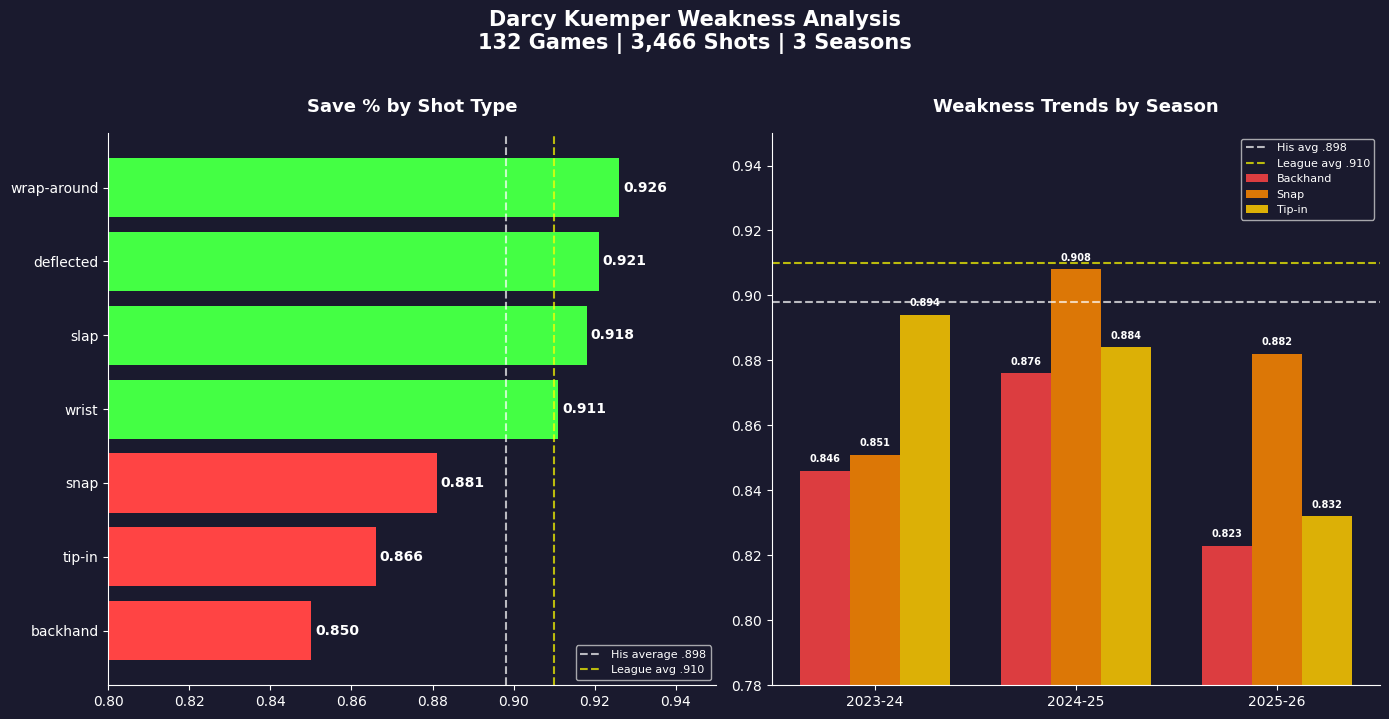

Chart saved as kuemper_analysis.png


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Set up the figure with two charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#1a1a2e')

# Chart 1: Save percentage by shot type
shot_data = kuemper_df.groupby('shot_type').agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).reset_index()
shot_data['save_pct'] = round(1 - shot_data['goals'] / shot_data['shots'], 3)
shot_data = shot_data[shot_data['shots'] >= 20]
shot_data = shot_data.sort_values('save_pct', ascending=True)

colors = ['#ff4444' if x < 0.890 else '#ffaa00' if x < 0.910 else '#44ff44' 
          for x in shot_data['save_pct']]

bars = ax1.barh(shot_data['shot_type'], shot_data['save_pct'], color=colors)
ax1.set_xlim(0.80, 0.95)
ax1.axvline(x=0.898, color='white', linestyle='--', alpha=0.7, label='His average .898')
ax1.axvline(x=0.910, color='yellow', linestyle='--', alpha=0.7, label='League avg .910')

for bar, val in zip(bars, shot_data['save_pct']):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', color='white', fontweight='bold')

ax1.set_facecolor('#1a1a2e')
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color('white')
ax1.spines['left'].set_color('white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title('Save % by Shot Type', color='white', fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='lower right', facecolor='#1a1a2e', labelcolor='white', fontsize=8)

# Chart 2: Backhand weakness trend across seasons
seasons = ['2023-24', '2024-25', '2025-26']
backhand_svpct = [0.846, 0.876, 0.823]
tipin_svpct = [0.894, 0.884, 0.832]
snap_svpct = [0.851, 0.908, 0.882]

x = np.arange(len(seasons))
width = 0.25

bars1 = ax2.bar(x - width, backhand_svpct, width, label='Backhand', color='#ff4444', alpha=0.85)
bars2 = ax2.bar(x, snap_svpct, width, label='Snap', color='#ff8800', alpha=0.85)
bars3 = ax2.bar(x + width, tipin_svpct, width, label='Tip-in', color='#ffcc00', alpha=0.85)

ax2.set_ylim(0.78, 0.95)
ax2.axhline(y=0.898, color='white', linestyle='--', alpha=0.7, label='His avg .898')
ax2.axhline(y=0.910, color='yellow', linestyle='--', alpha=0.7, label='League avg .910')
ax2.set_xticks(x)
ax2.set_xticklabels(seasons)
ax2.set_facecolor('#1a1a2e')
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color('white')
ax2.spines['left'].set_color('white')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('Weakness Trends by Season', color='white', fontsize=13, fontweight='bold', pad=15)
ax2.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.3f}', ha='center', va='bottom', 
                color='white', fontsize=7, fontweight='bold')

plt.suptitle('Darcy Kuemper Weakness Analysis\n132 Games | 3,466 Shots | 3 Seasons', 
             color='white', fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('kuemper_analysis.png', dpi=150, bbox_inches='tight', 
            facecolor='#1a1a2e', edgecolor='none')
plt.show()
print("Chart saved as kuemper_analysis.png")

In [28]:
# Chart 3: Shot location heat map style bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#1a1a2e')

# Left chart: Save pct by location
locations = ['Left Side', 'Center Ice', 'Right Side']
save_pcts = [0.950, 0.851, 0.953]
shot_counts = [860, 1859, 747]
colors = ['#44ff44', '#ff4444', '#44ff44']

bars = ax1.bar(locations, save_pcts, color=colors, alpha=0.85, width=0.5)
ax1.set_ylim(0.80, 1.00)
ax1.axhline(y=0.898, color='white', linestyle='--', alpha=0.7, label='His avg .898')
ax1.axhline(y=0.910, color='yellow', linestyle='--', alpha=0.7, label='League avg .910')

for bar, val, shots in zip(bars, save_pcts, shot_counts):
    ax1.text(bar.get_x() + bar.get_width()/2., val + 0.003,
             f'{val:.3f}', ha='center', va='bottom',
             color=

SyntaxError: unexpected EOF while parsing (1973047024.py, line 19)

In [29]:
# Chart 3: Shot location heat map style bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#1a1a2e')

# Left chart: Save pct by location
locations = ['Left Side', 'Center Ice', 'Right Side']
save_pcts = [0.950, 0.851, 0.953]
shot_counts = [860, 1859, 747]
colors = ['#44ff44', '#ff4444', '#44ff44']

bars = ax1.bar(locations, save_pcts, color=colors, alpha=0.85, width=0.5)
ax1.set_ylim(0.80, 1.00)
ax1.axhline(y=0.898, color='white', linestyle='--', alpha=0.7, label='His avg .898')
ax1.axhline(y=0.910, color='yellow', linestyle='--', alpha=0.7, label='League avg .910')

for bar, val, shots in zip(bars, save_pcts, shot_counts):
    ax1.text(bar.get_x() + bar.get_width()/2., val + 0.003,
             f'{val:.3f}', ha='center', va='bottom',
             color=

SyntaxError: unexpected EOF while parsing (1973047024.py, line 19)

In [27]:
# Chart 3: Shot location heat map style bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#1a1a2e')

# Left chart: Save pct by location
locations = ['Left Side', 'Center Ice', 'Right Side']
save_pcts = [0.950, 0.851, 0.953]
shot_counts = [860, 1859, 747]
colors = ['#44ff44', '#ff4444', '#44ff44']

bars = ax1.bar(locations, save_pcts, color=colors, alpha=0.85, width=0.5)
ax1.set_ylim(0.80, 1.00)
ax1.axhline(y=0.898, color='white', linestyle='--', alpha=0.7, label='His avg .898')
ax1.axhline(y=0.910, color='yellow', linestyle='--', alpha=0.7, label='League avg .910')

for bar, val, shots in zip(bars, save_pcts, shot_counts):
    ax1.text(bar.get_x() + bar.get_width()/2., val + 0.003,
             f'{val:.3f}', ha='center', va='bottom',
             color=

SyntaxError: unexpected EOF while parsing (1973047024.py, line 19)

Left chart done


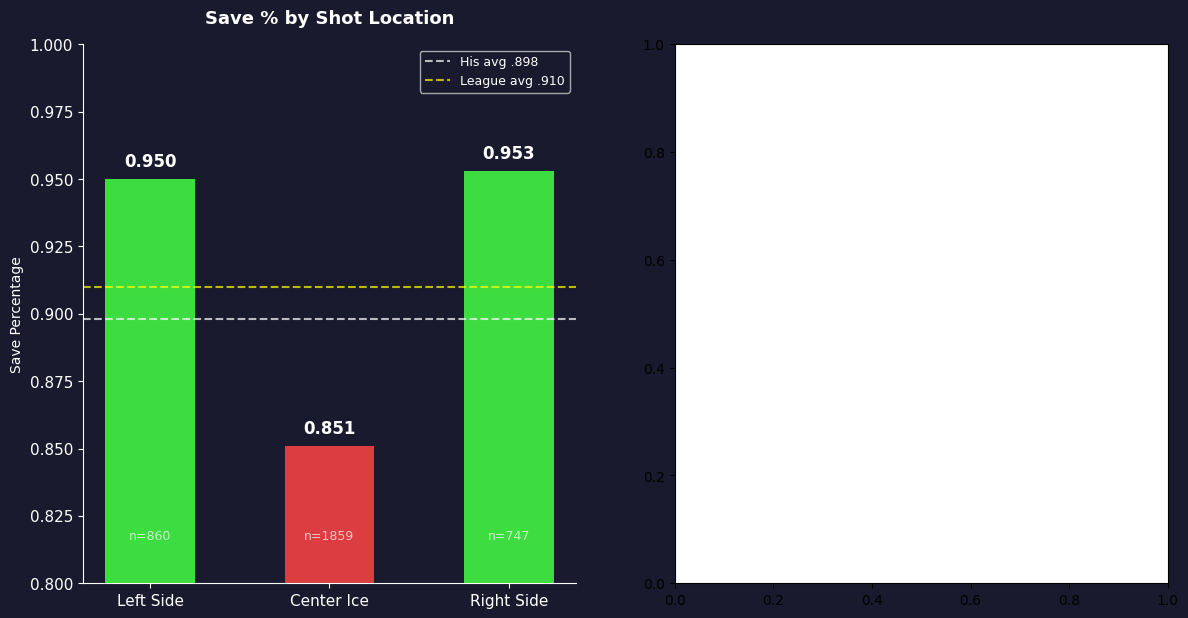

In [30]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#1a1a2e')

locations = ['Left Side', 'Center Ice', 'Right Side']
save_pcts = [0.950, 0.851, 0.953]
shot_counts = [860, 1859, 747]
colors = ['#44ff44', '#ff4444', '#44ff44']

bars = ax1.bar(locations, save_pcts, color=colors, alpha=0.85, width=0.5)
ax1.set_ylim(0.80, 1.00)
ax1.axhline(y=0.898, color='white', linestyle='--', alpha=0.7, label='His avg .898')
ax1.axhline(y=0.910, color='yellow', linestyle='--', alpha=0.7, label='League avg .910')

for bar, val, shots in zip(bars, save_pcts, shot_counts):
    ax1.text(bar.get_x() + bar.get_width()/2., val + 0.003,
             f'{val:.3f}', ha='center', va='bottom',
             color='white', fontsize=12, fontweight='bold')
    ax1.text(bar.get_x() + bar.get_width()/2., 0.815,
             f'n={shots}', ha='center', va='bottom',
             color='white', fontsize=9, alpha=0.7)

ax1.set_facecolor('#1a1a2e')
ax1.tick_params(colors='white', labelsize=11)
ax1.spines['bottom'].set_color('white')
ax1.spines['left'].set_color('white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title('Save % by Shot Location', color='white',
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax1.set_ylabel('Save Percentage', color='white')

print("Left chart done")

In [31]:
combos = ['Backhand\nCenter', 'Snap\nCenter', 'Tip-in\nCenter',
          'Wrist\nCenter', 'Wrist\nLeft', 'Wrist\nRight']
combo_pcts = [0.815, 0.825, 0.855, 0.855, 0.965, 0.963]
combo_shots = [211, 309, 235, 881, 518, 410]
combo_colors = ['#ff2222', '#ff4444', '#ff6666',
                '#ff8888', '#44ff44', '#44ff44']

bars2 = ax2.barh(combos, combo_pcts, color=combo_colors, alpha=0.85)
ax2.set_xlim(0.78, 1.00)
ax2.axvline(x=0.898, color='white', linestyle='--', alpha=0.7, label='His avg .898')
ax2.axvline(x=0.910, color='yellow', linestyle='--', alpha=0.7, label='League avg .910')

for bar, val, shots in zip(bars2, combo_pcts, combo_shots):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f} (n={shots})', va='center',
             color='white', fontsize=9, fontweight='bold')

ax2.set_facecolor('#1a1a2e')
ax2.tick_params(colors='white', labelsize=10)
ax2.spines['bottom'].set_color('white')
ax2.spines['left'].set_color('white')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('Best Shot Type + Location Combos\nto Beat Kuemper',
              color='white', fontsize=13, fontweight='bold', pad=15)
ax2.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)

plt.suptitle('Darcy Kuemper: Where to Shoot\nOilers vs Kings | Friday Night',
             color='white', fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('kuemper_location_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e', edgecolor='none')
plt.show()
print("Chart saved as kuemper_location_analysis.png")

<Figure size 640x480 with 0 Axes>

Chart saved as kuemper_location_analysis.png


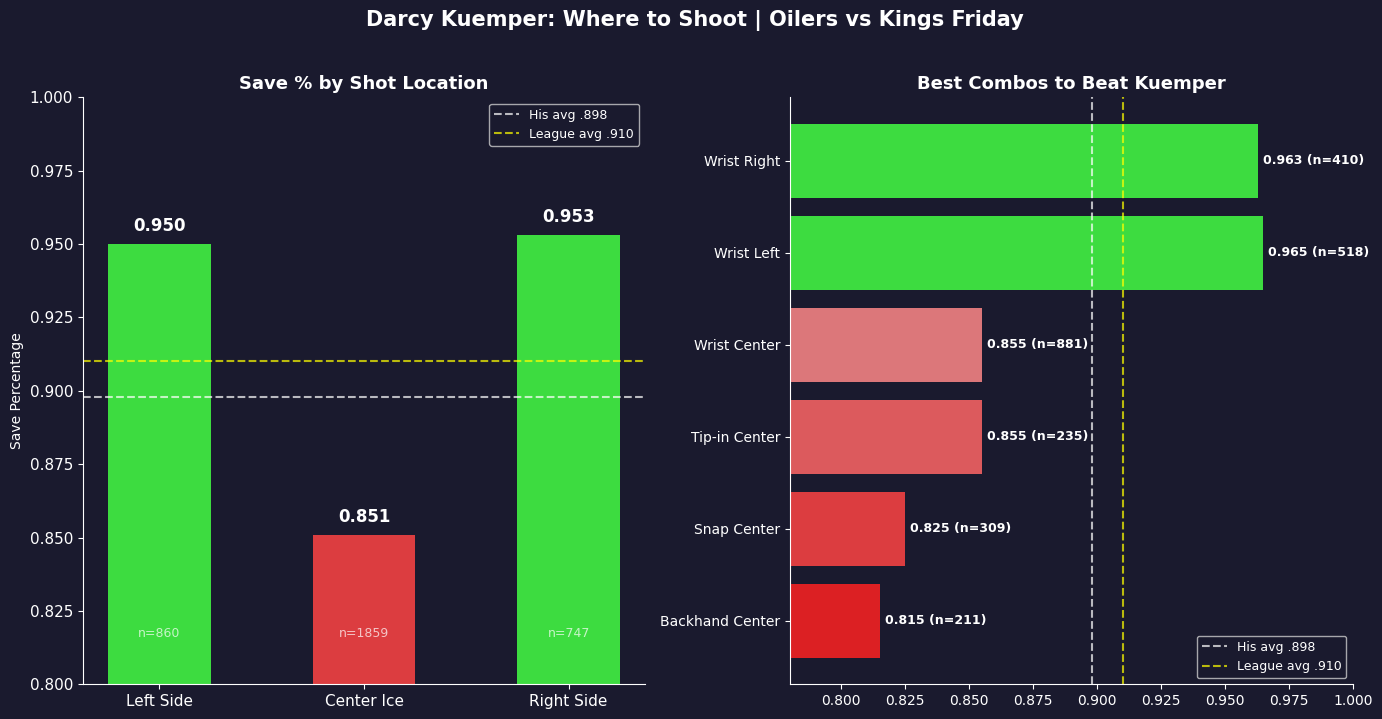

Saved successfully


In [32]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#1a1a2e')

# Left chart data
locations = ['Left Side', 'Center Ice', 'Right Side']
save_pcts = [0.950, 0.851, 0.953]
shot_counts = [860, 1859, 747]
colors = ['#44ff44', '#ff4444', '#44ff44']

# Left chart bars
bars = ax1.bar(locations, save_pcts, color=colors, alpha=0.85, width=0.5)
ax1.set_ylim(0.80, 1.00)
ax1.axhline(y=0.898, color='white', linestyle='--', alpha=0.7, label='His avg .898')
ax1.axhline(y=0.910, color='yellow', linestyle='--', alpha=0.7, label='League avg .910')
ax1.set_facecolor('#1a1a2e')
ax1.tick_params(colors='white', labelsize=11)
ax1.spines['bottom'].set_color('white')
ax1.spines['left'].set_color('white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title('Save % by Shot Location', color='white', fontsize=13, fontweight='bold')
ax1.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax1.set_ylabel('Save Percentage', color='white')

for bar, val, shots in zip(bars, save_pcts, shot_counts):
    ax1.text(bar.get_x() + bar.get_width()/2., val + 0.003,
             f'{val:.3f}', ha='center', va='bottom',
             color='white', fontsize=12, fontweight='bold')
    ax1.text(bar.get_x() + bar.get_width()/2., 0.815,
             f'n={shots}', ha='center', va='bottom',
             color='white', fontsize=9, alpha=0.7)

# Right chart data
combos = ['Backhand Center', 'Snap Center', 'Tip-in Center',
          'Wrist Center', 'Wrist Left', 'Wrist Right']
combo_pcts = [0.815, 0.825, 0.855, 0.855, 0.965, 0.963]
combo_shots = [211, 309, 235, 881, 518, 410]
combo_colors = ['#ff2222', '#ff4444', '#ff6666',
                '#ff8888', '#44ff44', '#44ff44']

# Right chart bars
bars2 = ax2.barh(combos, combo_pcts, color=combo_colors, alpha=0.85)
ax2.set_xlim(0.78, 1.00)
ax2.axvline(x=0.898, color='white', linestyle='--', alpha=0.7, label='His avg .898')
ax2.axvline(x=0.910, color='yellow', linestyle='--', alpha=0.7, label='League avg .910')
ax2.set_facecolor('#1a1a2e')
ax2.tick_params(colors='white', labelsize=10)
ax2.spines['bottom'].set_color('white')
ax2.spines['left'].set_color('white')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('Best Combos to Beat Kuemper',
              color='white', fontsize=13, fontweight='bold')
ax2.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)

for bar, val, shots in zip(bars2, combo_pcts, combo_shots):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f} (n={shots})', va='center',
             color='white', fontsize=9, fontweight='bold')

plt.suptitle('Darcy Kuemper: Where to Shoot | Oilers vs Kings Friday',
             color='white', fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('kuemper_location_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e', edgecolor='none')
plt.show()
print("Saved successfully")

In [ ]:
print(len(kuemper_df))
print(kuemper_df.columns.tolist())

In [ ]:
print(len(kuemper_df))
print(kuemper_df.columns.tolist())

In [ ]:
import pandas as pd
kuemper_df = pd.read_csv('kuemper_shots_all_seasons.csv')
print(len(kuemper_df))

In [ ]:
import pandas as pd
kuemper_df = pd.read_csv('kuemper_shots_all_seasons.csv')
print(len(kuemper_df))

In [ ]:
import pandas as pd
import os

kuemper_df = pd.read_csv('kuemper_shots_all_seasons.csv')
print("Rows:", len(kuemper_df))
print("Columns:", kuemper_df.columns.tolist())

In [ ]:
import os
print(os.getcwd())

In [1]:
print("hello")

hello


In [2]:
import pandas as pd
import os

print(os.getcwd())

/Users/ashgarg/Library/CloudStorage/OneDrive-Personal/NHL analysis/Goalies/Kuemper


In [3]:
import pandas as pd

kuemper_df = pd.read_csv('/Users/ashgarg/Library/CloudStorage/OneDrive-Personal/NHL analysis/Kuemper/kuemper_shots_all_seasons.csv')
print("Rows:", len(kuemper_df))
print("Columns:", kuemper_df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ashgarg/Library/CloudStorage/OneDrive-Personal/NHL analysis/Kuemper/kuemper_shots_all_seasons.csv'

In [4]:
import os

base = '/Users/ashgarg/Library/CloudStorage/OneDrive-Personal/NHL analysis'

for root, dirs, files in os.walk(base):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/Users/ashgarg/Library/CloudStorage/OneDrive-Personal/NHL analysis/Goalies/Kuemper/kuemper_shots_all_seasons.csv


In [5]:
import pandas as pd

kuemper_df = pd.read_csv('/Users/ashgarg/Library/CloudStorage/OneDrive-Personal/NHL analysis/Goalies/Kuemper/kuemper_shots_all_seasons.csv')
print("Rows:", len(kuemper_df))
print("Columns:", kuemper_df.columns.tolist())

Rows: 3466
Columns: ['game_id', 'game_date', 'period', 'time', 'shot_type', 'shooting_player_id', 'x_coord', 'y_coord', 'zone', 'is_goal', 'situation_code']


In [6]:
import requests
import time

def get_player_handedness(player_id):
    """Get shooting hand for a player"""
    url = f"https://api-web.nhle.com/v1/player/{int(player_id)}/landing"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            shoots = data.get('shootsCatches')
            return shoots
        else:
            return None
    except:
        return None

# Get all unique shooter IDs
unique_shooters = kuemper_df['shooting_player_id'].dropna().unique()
print(f"Total unique shooters to look up: {len(unique_shooters)}")

# Pull handedness for each shooter
handedness_dict = {}
for i, player_id in enumerate(unique_shooters):
    hand = get_player_handedness(player_id)
    handedness_dict[player_id] = hand
    if (i + 1) % 20 == 0:
        print(f"Progress: {i+1}/{len(unique_shooters)} players looked up")
    time.sleep(0.2)

print(f"\nCompleted! Found handedness for {sum(1 for v in handedness_dict.values() if v)} players")
print("Sample of results:")
for k, v in list(handedness_dict.items())[:5]:
    print(f"Player ID {k}: shoots {v}")

/Users/ashgarg/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Total unique shooters to look up: 711
Progress: 20/711 players looked up
Progress: 40/711 players looked up
Progress: 60/711 players looked up
Progress: 80/711 players looked up
Progress: 100/711 players looked up
Progress: 120/711 players looked up
Progress: 140/711 players looked up
Progress: 160/711 players looked up
Progress: 180/711 players looked up
Progress: 200/711 players looked up
Progress: 220/711 players looked up
Progress: 240/711 players looked up
Progress: 260/711 players looked up
Progress: 280/711 players looked up
Progress: 300/711 players looked up
Progress: 320/711 players looked up
Progress: 340/711 players looked up
Progress: 360/711 players looked up
Progress: 380/711 players looked up
Progress: 400/711 players looked up
Progress: 420/711 players looked up
Progress: 440/711 players looked up
Progress: 460/711 players looked up
Progress: 480/711 players looked up
Progress: 500/711 players looked up
Progress: 520/711 players looked up
Progress: 540/711 players look

In [7]:
# Add handedness to dataframe
kuemper_df['shoots'] = kuemper_df['shooting_player_id'].map(handedness_dict)

# Verify it worked
print("Handedness breakdown of all shots:")
print(kuemper_df['shoots'].value_counts())
print(f"\nMissing handedness: {kuemper_df['shoots'].isna().sum()} shots")

Handedness breakdown of all shots:
shoots
L    1920
R    1191
Name: count, dtype: int64

Missing handedness: 355 shots


In [8]:
# Add location column back since it was lost when we reloaded
import pandas as pd

kuemper_df['location'] = pd.cut(
    kuemper_df['y_coord'],
    bins=[-50, -15, 15, 50],
    labels=['Left', 'Center', 'Right']
)

# The big analysis - handedness + shot type + location
handedness_analysis = kuemper_df.groupby(
    ['shoots', 'shot_type', 'location']
).agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).reset_index()

handedness_analysis['save_pct'] = round(
    1 - handedness_analysis['goals'] / handedness_analysis['shots'], 3
)

# Filter for meaningful sample sizes
handedness_filtered = handedness_analysis[handedness_analysis['shots'] >= 15]

# Sort by save percentage ascending so worst is at top
handedness_filtered = handedness_filtered.sort_values('save_pct', ascending=True)

print("Kuemper's Biggest Weaknesses by Shooter Handedness")
print("===================================================")
print(handedness_filtered.head(20).to_string(index=False))

Kuemper's Biggest Weaknesses by Shooter Handedness
shoots   shot_type location  shots  goals  save_pct
     L    backhand     Left     21      0       1.0
     R       wrist     Left    211      0       1.0
     R      tip-in   Center     63      0       1.0
     R        snap    Right     65      0       1.0
     R        snap   Center     92      0       1.0
     R        snap     Left     63      0       1.0
     R        slap    Right     59      0       1.0
     R        slap   Center     51      0       1.0
     R        slap     Left     44      0       1.0
     R   deflected   Center     23      0       1.0
     R    backhand   Center     59      0       1.0
     L       wrist    Right    245      0       1.0
     L       wrist   Center    487      0       1.0
     L       wrist     Left    289      0       1.0
     L wrap-around   Center     18      0       1.0
     L      tip-in   Center    138      0       1.0
     L        snap    Right     87      0       1.0
     L       

/var/folders/4d/vc6n3qb90359q2q3j5v10r6w0000gn/T/ipykernel_70512/3316365301.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  handedness_analysis = kuemper_df.groupby(


In [9]:
print("Is goal breakdown:")
print(kuemper_df['is_goal'].value_counts())
print("\nSample of is_goal column:")
print(kuemper_df['is_goal'].head(10))
print("\nData type:", kuemper_df['is_goal'].dtype)

Is goal breakdown:
is_goal
0    3111
1     355
Name: count, dtype: int64

Sample of is_goal column:
0    0
1    0
2    0
3    0
4    1
5    1
6    0
7    0
8    0
9    1
Name: is_goal, dtype: int64

Data type: int64


In [10]:
# Check if goals have missing handedness
print("Goals with missing handedness:")
print(kuemper_df[kuemper_df['is_goal'] == 1]['shoots'].value_counts(dropna=False))

print("\nSaves with missing handedness:")
print(kuemper_df[kuemper_df['is_goal'] == 0]['shoots'].value_counts(dropna=False))

Goals with missing handedness:
shoots
NaN    355
Name: count, dtype: int64

Saves with missing handedness:
shoots
L    1920
R    1191
Name: count, dtype: int64


In [11]:
# Check a few goals to understand the data
print("Sample of goal rows:")
print(kuemper_df[kuemper_df['is_goal'] == 1][['game_id', 'game_date', 'shot_type', 'shooting_player_id', 'x_coord', 'y_coord']].head(10))

Sample of goal rows:
       game_id   game_date shot_type  shooting_player_id  x_coord  y_coord
4   2025021217  2026-04-04      snap                 NaN       54        6
5   2025021217  2026-04-04      snap                 NaN       64        2
9   2025021217  2026-04-04     wrist                 NaN      -85        3
13  2025021217  2026-04-04     wrist                 NaN      -82        0
17  2025021217  2026-04-04     wrist                 NaN       66        5
18  2025021217  2026-04-04     wrist                 NaN       69      -21
21  2025021204  2026-04-02     wrist                 NaN       84       35
25  2025021204  2026-04-02  backhand                 NaN       82        0
39  2025021204  2026-04-02     wrist                 NaN      -73       15
42  2025021204  2026-04-02     wrist                 NaN      -84        7


In [12]:
import requests

def check_goal_fields(game_id):
    """Look at raw goal event data to find correct field names"""
    url = f"https://api-web.nhle.com/v1/gamecenter/{game_id}/play-by-play"
    response = requests.get(url, timeout=10)
    if response.status_code == 200:
        data = response.json()
        plays = data.get('plays', [])
        for play in plays:
            if play.get('typeCode') == 505:
                print("Goal event details field:")
                print(play.get('details'))
                print("\nFull goal event:")
                import json
                print(json.dumps(play, indent=2))
                break

check_goal_fields(2025021217)

Goal event details field:
{'xCoord': 54, 'yCoord': 6, 'zoneCode': 'O', 'shotType': 'snap', 'scoringPlayerId': 8482720, 'scoringPlayerTotal': 22, 'assist1PlayerId': 8477503, 'assist1PlayerTotal': 24, 'eventOwnerTeamId': 10, 'goalieInNetId': 8475311, 'awayScore': 1, 'homeScore': 0, 'highlightClipSharingUrl': 'https://nhl.com/video/tor-lak-knies-scores-goal-against-darcy-kuemper-6392584531112', 'highlightClipSharingUrlFr': 'https://nhl.com/fr/video/tor-lak-knies-marque-un-but-contre-darcy-kuemper-6392583833112', 'highlightClip': 6392584531112, 'highlightClipFr': 6392583833112, 'discreteClip': 6392584524112, 'discreteClipFr': 6392584225112}

Full goal event:
{
  "eventId": 124,
  "periodDescriptor": {
    "number": 1,
    "periodType": "REG",
    "maxRegulationPeriods": 3
  },
  "timeInPeriod": "04:19",
  "timeRemaining": "15:41",
  "situationCode": "1441",
  "homeTeamDefendingSide": "right",
  "typeCode": 505,
  "typeDescKey": "goal",
  "sortOrder": 77,
  "details": {
    "xCoord": 54,
  

In [13]:
print(len(all_kuemper_games))

NameError: name 'all_kuemper_games' is not defined

In [14]:
import requests
import time
import pandas as pd

def get_goalie_game_log(player_id, season):
    """Get every game a goalie played in a season"""
    url = f"https://api-web.nhle.com/v1/player/{player_id}/game-log/{season}/2"
    response = requests.get(url, timeout=10)
    if response.status_code == 200:
        data = response.json()
        games = data.get('gameLog', [])
        print(f"Found {len(games)} games for {season}")
        return games
    else:
        print(f"Error: {response.status_code}")
        return []

# Pull all three season game logs
games_2526 = get_goalie_game_log(8475311, "20252026")
games_2425 = get_goalie_game_log(8475311, "20242025")
games_2324 = get_goalie_game_log(8475311, "20232024")

# Combine
all_kuemper_games = games_2526 + games_2425 + games_2324
print(f"\nTotal games: {len(all_kuemper_games)}")

Found 49 games for 20252026
Found 50 games for 20242025
Found 33 games for 20232024

Total games: 132


In [ ]:
def get_kuemper_shots_fixed(games_list, kuemper_id=8475311):
    """Extract all shots faced by Kuemper with corrected shooter ID for goals"""
    all_shots = []
    total_games = len(games_list)
    
    for i, game in enumerate(games_list):
        game_id = game.get('gameId')
        game_date = game.get('gameDate')
        
        url = f"https://api-web.nhle.com/v1/gamecenter/{game_id}/play-by-play"
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            game_data = response.json()
            plays = game_data.get('plays', [])
            
            for play in plays:
                type_code = play.get('typeCode')
                
                if type_code in [505, 506]:
                    details = play.get('details', {})
                    goalie_in_net = details.get('goalieInNetId')
                    
                    if goalie_in_net == kuemper_id:
                        if type_code == 505:
                            shooter_id = details.get('scoringPlayerId')
                        else:
                            shooter_id = details.get('shootingPlayerId')
                        
                        shot = {
                            'game_id': game_id,
                            'game_date': game_date,
                            'period': play.get('periodDescriptor', {}).get('number'),
                            'time': play.get('timeInPeriod'),
                            'shot_type': details.get('shotType'),
                            'shooting_player_id': shooter_id,
                            'x_coord': details.get('xCoord'),
                            'y_coord': details.get('yCoord'),
                            'zone': details.get('zoneCode'),
                            'is_goal': 1 if type_code == 505 else 0,
                            'situation_code': play.get('situationCode')
                        }
                        all_shots.append(shot)
        
        if (i + 1) % 10 == 0:
            print(f"Progress: {i+1}/{total_games} games | {len(all_shots)} shots so far")
        
        time.sleep(0.3)
    
    print(f"\nCompleted! Total shots: {len(all_shots)}")
    return all_shots

print("Re-pulling all 132 games with corrected code...")
print("This will take about 7-8 minutes\n")

shots_fixed = get_kuemper_shots_fixed(all_kuemper_games)


In [15]:
import requests
import time
import pandas as pd
print("imports done")

imports done


In [16]:
def get_kuemper_shots_fixed(games_list, kuemper_id=8475311):
    all_shots = []
    total_games = len(games_list)
    
    for i, game in enumerate(games_list):
        game_id = game.get('gameId')
        game_date = game.get('gameDate')
        
        url = f"https://api-web.nhle.com/v1/gamecenter/{game_id}/play-by-play"
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            game_data = response.json()
            plays = game_data.get('plays', [])
            
            for play in plays:
                type_code = play.get('typeCode')
                
                if type_code in [505, 506]:
                    details = play.get('details', {})
                    goalie_in_net = details.get('goalieInNetId')
                    
                    if goalie_in_net == kuemper_id:
                        if type_code == 505:
                            shooter_id = details.get('scoringPlayerId')
                        else:
                            shooter_id = details.get('shootingPlayerId')
                        
                        shot = {
                            'game_id': game_id,
                            'game_date': game_date,
                            'period': play.get('periodDescriptor', {}).get('number'),
                            'time': play.get('timeInPeriod'),
                            'shot_type': details.get('shotType'),
                            'shooting_player_id': shooter_id,
                            'x_coord': details.get('xCoord'),
                            'y_coord': details.get('yCoord'),
                            'zone': details.get('zoneCode'),
                            'is_goal': 1 if type_code == 505 else 0,
                            'situation_code': play.get('situationCode')
                        }
                        all_shots.append(shot)
        
        if (i + 1) % 10 == 0:
            print(f"Progress: {i+1}/{total_games} games | {len(all_shots)} shots so far")
        
        time.sleep(0.3)
    
    print(f"Completed! Total shots: {len(all_shots)}")
    return all_shots

print("Function loaded")

Function loaded


In [17]:
print("Starting pull...")
shots_fixed = get_kuemper_shots_fixed(all_kuemper_games)

Starting pull...
Progress: 10/132 games | 246 shots so far
Progress: 20/132 games | 492 shots so far
Progress: 30/132 games | 729 shots so far
Progress: 40/132 games | 994 shots so far
Progress: 50/132 games | 1259 shots so far
Progress: 60/132 games | 1493 shots so far
Progress: 70/132 games | 1746 shots so far
Progress: 80/132 games | 2003 shots so far
Progress: 90/132 games | 2275 shots so far
Progress: 100/132 games | 2561 shots so far
Progress: 110/132 games | 2816 shots so far
Progress: 120/132 games | 3110 shots so far
Progress: 130/132 games | 3396 shots so far
Completed! Total shots: 3466


In [ ]:
# Convert to dataframe
kuemper_df = pd.DataFrame(shots_fixed)

# Save corrected CSV overwriting the old one
kuemper_df.to_csv('/Users/ashgarg/Library/CloudStorage/OneDrive-Personal/NHL analysis/Goalies/Kuemper/kuemper_shots_all_seasons.csv', index=False)

# Verify goals now have shooter IDs
print("Goals with shooter ID:")
print(kuemper_df[kuemper_df['is_goal'] == 1]['shooting_player_id'].isna().value_counts())

print("\nOverall stats:")
print(f"Total shots: {len(kuemper_df)}")
print(f"Total goals: {kuemper_df['is_goal'].sum()}")
print(f"Save percentage: {round(1 - kuemper_df['is_goal'].mean(), 3)}")


In [18]:
kuemper_df = pd.DataFrame(shots_fixed)
print(len(kuemper_df))

3466


In [19]:
# Convert to dataframe
kuemper_df = pd.DataFrame(shots_fixed)

# Save corrected CSV overwriting the old one
kuemper_df.to_csv('/Users/ashgarg/Library/CloudStorage/OneDrive-Personal/NHL analysis/Goalies/Kuemper/kuemper_shots_all_seasons.csv', index=False)

# Verify goals now have shooter IDs
print("Goals with shooter ID:")
print(kuemper_df[kuemper_df['is_goal'] == 1]['shooting_player_id'].isna().value_counts())

print("\nOverall stats:")
print(f"Total shots: {len(kuemper_df)}")
print(f"Total goals: {kuemper_df['is_goal'].sum()}")
print(f"Save percentage: {round(1 - kuemper_df['is_goal'].mean(), 3)}")

Goals with shooter ID:
shooting_player_id
False    355
Name: count, dtype: int64

Overall stats:
Total shots: 3466
Total goals: 355
Save percentage: 0.898


In [20]:
# Get all unique shooter IDs including goal scorers
unique_shooters = kuemper_df['shooting_player_id'].dropna().unique()
print(f"Total unique shooters: {len(unique_shooters)}")

# Pull handedness for each shooter
handedness_dict = {}
for i, player_id in enumerate(unique_shooters):
    url = f"https://api-web.nhle.com/v1/player/{int(player_id)}/landing"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            handedness_dict[player_id] = data.get('shootsCatches')
    except:
        handedness_dict[player_id] = None
    
    if (i + 1) % 20 == 0:
        print(f"Progress: {i+1}/{len(unique_shooters)} players looked up")
    
    time.sleep(0.2)

# Add to dataframe
kuemper_df['shoots'] = kuemper_df['shooting_player_id'].map(handedness_dict)

print("\nHandedness breakdown:")
print(kuemper_df['shoots'].value_counts())
print(f"Missing: {kuemper_df['shoots'].isna().sum()}")

Total unique shooters: 724
Progress: 20/724 players looked up
Progress: 40/724 players looked up
Progress: 60/724 players looked up
Progress: 80/724 players looked up
Progress: 100/724 players looked up
Progress: 120/724 players looked up
Progress: 140/724 players looked up
Progress: 160/724 players looked up
Progress: 180/724 players looked up
Progress: 200/724 players looked up
Progress: 220/724 players looked up
Progress: 240/724 players looked up
Progress: 260/724 players looked up
Progress: 280/724 players looked up
Progress: 300/724 players looked up
Progress: 320/724 players looked up
Progress: 340/724 players looked up
Progress: 360/724 players looked up
Progress: 380/724 players looked up
Progress: 400/724 players looked up
Progress: 420/724 players looked up
Progress: 440/724 players looked up
Progress: 460/724 players looked up
Progress: 480/724 players looked up
Progress: 500/724 players looked up
Progress: 520/724 players looked up
Progress: 540/724 players looked up
Progr

In [21]:
import pandas as pd

# Add location column
kuemper_df['location'] = pd.cut(
    kuemper_df['y_coord'],
    bins=[-50, -15, 15, 50],
    labels=['Left', 'Center', 'Right']
)

# Handedness + shot type + location analysis
handedness_analysis = kuemper_df.groupby(
    ['shoots', 'shot_type', 'location'],
    observed=True
).agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).reset_index()

handedness_analysis['save_pct'] = round(
    1 - handedness_analysis['goals'] / handedness_analysis['shots'], 3
)

# Filter for meaningful sample sizes
handedness_filtered = handedness_analysis[
    handedness_analysis['shots'] >= 15
].sort_values('save_pct', ascending=True)

print("Kuemper Weakness by Handedness + Shot Type + Location")
print("======================================================")
print(handedness_filtered.head(20).to_string(index=False))

Kuemper Weakness by Handedness + Shot Type + Location
shoots shot_type location  shots  goals  save_pct
     R  backhand   Center     76     17     0.776
     L      snap   Center    198     35     0.823
     R      snap   Center    111     19     0.829
     L  backhand   Center    135     22     0.837
     R    tip-in   Center     75     12     0.840
     R     wrist   Center    315     49     0.844
     L     wrist   Center    566     79     0.860
     L    tip-in   Center    160     22     0.862
     R      slap     Left     50      6     0.880
     R      slap   Center     57      6     0.895
     R      snap     Left     70      7     0.900
     L deflected   Center     31      3     0.903
     R      slap    Right     65      6     0.908
     L      snap    Right     95      8     0.916
     R deflected   Center     25      2     0.920
     L      slap     Left     66      5     0.924
     L      slap   Center     51      3     0.941
     L      snap     Left    107      6     0.

In [22]:
# Look up key Oilers right handed shooters
oilers_righties = {
    'Savoie': 8483515,
    'Roslovic': 8478476,
    'Lazar': 8478012,
    'Kapanen': 8478396,
    'Dach': 8481600,
    'Bouchard': 8480803,
    'Murphy': 8476462,
    'Emberson': 8481533
}

print("Oilers Right Handed Players:")
print("=============================")
for name, player_id in oilers_righties.items():
    url = f"https://api-web.nhle.com/v1/player/{player_id}/landing"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            shoots = data.get('shootsCatches')
            position = data.get('position')
            print(f"{name}: shoots {shoots} | position {position}")
    except:
        print(f"{name}: lookup failed")
    time.sleep(0.2)

Oilers Right Handed Players:
Savoie: shoots L | position L
Roslovic: shoots L | position D
Lazar: shoots L | position L
Kapanen: shoots L | position D
Dach: shoots L | position D
Bouchard: shoots R | position D
Murphy: shoots R | position D
Emberson: shoots L | position C


In [23]:
def find_player_id(last_name, team="EDM"):
    url = f"https://api-web.nhle.com/v1/roster/{team}/20252026"
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        all_players = (data.get('forwards', []) + 
                      data.get('defensemen', []) + 
                      data.get('goalies', []))
        for player in all_players:
            last = player.get('lastName', {}).get('default', '')
            first = player.get('firstName', {}).get('default', '')
            if last_name.lower() in last.lower():
                player_id = player.get('id')
                shoots = player.get('shootsCatches')
                position = player.get('positionCode')
                print(f"{first} {last}: ID {player_id} | shoots {shoots} | position {position}")

# Look up each player from current Oilers roster
names = ['Savoie', 'Roslovic', 'Lazar', 'Kapanen', 'Dach', 
         'Bouchard', 'Murphy', 'Emberson']

print("Current Oilers Roster Lookup:")
print("==============================")
for name in names:
    find_player_id(name)
    time.sleep(0.2)


Current Oilers Roster Lookup:
Matt Savoie: ID 8483512 | shoots R | position C
Jack Roslovic: ID 8478458 | shoots R | position C
Curtis Lazar: ID 8477508 | shoots R | position C
Kasperi Kapanen: ID 8477953 | shoots R | position R
Colton Dach: ID 8482703 | shoots L | position C
Evan Bouchard: ID 8480803 | shoots R | position D
Connor Murphy: ID 8476473 | shoots R | position D
Ty Emberson: ID 8480834 | shoots R | position D


In [24]:
# Check if these Oilers players appear in our shot data
oilers_righties_correct = {
    'Savoie': 8483512,
    'Roslovic': 8478458,
    'Lazar': 8477508,
    'Kapanen': 8477953,
    'Bouchard': 8480803,
    'Murphy': 8476473,
    'Emberson': 8480834
}

print("Oilers Players in Kuemper Shot Data:")
print("=====================================")
for name, player_id in oilers_righties_correct.items():
    player_shots = kuemper_df[
        kuemper_df['shooting_player_id'] == player_id
    ]
    goals = player_shots['is_goal'].sum()
    shots = len(player_shots)
    if shots > 0:
        sv_pct = round(1 - goals/shots, 3)
        print(f"{name}: {shots} shots | {goals} goals | save pct against {sv_pct}")
    else:
        print(f"{name}: No shots in dataset")
    time.sleep(0.1)
    

Oilers Players in Kuemper Shot Data:
Savoie: No shots in dataset
Roslovic: No shots in dataset
Lazar: No shots in dataset
Kapanen: 4 shots | 1 goals | save pct against 0.75
Bouchard: 13 shots | 0 goals | save pct against 1.0
Murphy: 9 shots | 1 goals | save pct against 0.889
Emberson: 4 shots | 1 goals | save pct against 0.75


In [25]:
# Save final complete dataset with handedness
kuemper_df.to_csv('/Users/ashgarg/Library/CloudStorage/OneDrive-Personal/NHL analysis/Goalies/Kuemper/kuemper_shots_all_seasons.csv', index=False)
print("Saved complete dataset with handedness column")
print(f"Columns: {kuemper_df.columns.tolist()}")
print(f"Total rows: {len(kuemper_df)}")

Saved complete dataset with handedness column
Columns: ['game_id', 'game_date', 'period', 'time', 'shot_type', 'shooting_player_id', 'x_coord', 'y_coord', 'zone', 'is_goal', 'situation_code', 'shoots', 'location']
Total rows: 3466


In [26]:
# Verify the right handed backhand center finding
rh_backhand_center = kuemper_df[
    (kuemper_df['shoots'] == 'R') & 
    (kuemper_df['shot_type'] == 'backhand') & 
    (kuemper_df['location'] == 'Center')
]

print(f"Total shots in this category: {len(rh_backhand_center)}")
print(f"Goals: {rh_backhand_center['is_goal'].sum()}")
print(f"Save percentage: {round(1 - rh_backhand_center['is_goal'].mean(), 3)}")
print(f"\nSpread across seasons:")
print(rh_backhand_center.groupby('game_date').size().describe())

Total shots in this category: 76
Goals: 17
Save percentage: 0.776

Spread across seasons:
count    51.000000
mean      1.490196
std       0.758223
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max       4.000000
dtype: float64


In [27]:
# Full handedness analysis for all shot types
handedness_summary = kuemper_df.groupby(
    ['shoots', 'shot_type'],
    observed=True
).agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).reset_index()

handedness_summary['save_pct'] = round(
    1 - handedness_summary['goals'] / handedness_summary['shots'], 3
)

# Filter meaningful sample sizes
handedness_summary = handedness_summary[
    handedness_summary['shots'] >= 20
].sort_values('save_pct', ascending=True)

print("Kuemper Save % by Handedness and Shot Type")
print("===========================================")
print(handedness_summary.to_string(index=False))

Kuemper Save % by Handedness and Shot Type
shoots shot_type  shots  goals  save_pct
     R  backhand     97     17     0.825
     R    tip-in     81     12     0.852
     L  backhand    169     23     0.864
     L    tip-in    172     22     0.872
     L      snap    400     49     0.878
     R      snap    248     28     0.887
     R      slap    172     18     0.895
     R     wrist    690     63     0.909
     L     wrist   1119     98     0.912
     L deflected     37      3     0.919
     R deflected     26      2     0.923
     L      slap    194     12     0.938


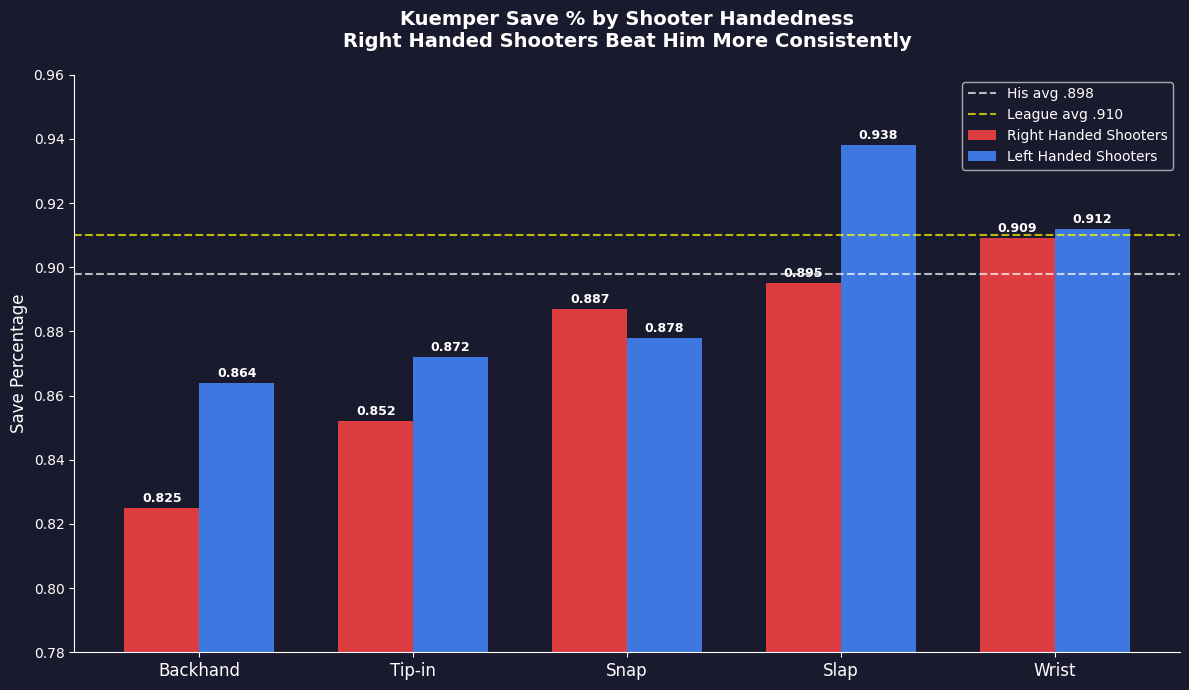

Saved as kuemper_handedness.png


In [28]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

# Data for chart
shot_types = ['Backhand', 'Tip-in', 'Snap', 'Slap', 'Wrist']
right_handed = [0.825, 0.852, 0.887, 0.895, 0.909]
left_handed = [0.864, 0.872, 0.878, 0.938, 0.912]

x = np.arange(len(shot_types))
width = 0.35

bars1 = ax.bar(x - width/2, right_handed, width, 
               label='Right Handed Shooters', 
               color='#ff4444', alpha=0.85)
bars2 = ax.bar(x + width/2, left_handed, width, 
               label='Left Handed Shooters', 
               color='#4488ff', alpha=0.85)

ax.set_ylim(0.78, 0.96)
ax.axhline(y=0.898, color='white', linestyle='--', 
           alpha=0.7, label='His avg .898')
ax.axhline(y=0.910, color='yellow', linestyle='--', 
           alpha=0.7, label='League avg .910')

ax.set_xticks(x)
ax.set_xticklabels(shot_types, color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Save Percentage', color='white', fontsize=12)
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=10)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
            f'{height:.3f}', ha='center', va='bottom',
            color='white', fontsize=9, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
            f'{height:.3f}', ha='center', va='bottom',
            color='white', fontsize=9, fontweight='bold')

ax.set_title('Kuemper Save % by Shooter Handedness\nRight Handed Shooters Beat Him More Consistently',
             color='white', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/Users/ashgarg/Library/CloudStorage/OneDrive-Personal/NHL analysis/Goalies/Kuemper/kuemper_handedness.png',
            dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e', edgecolor='none')
plt.show()
print("Saved as kuemper_handedness.png")

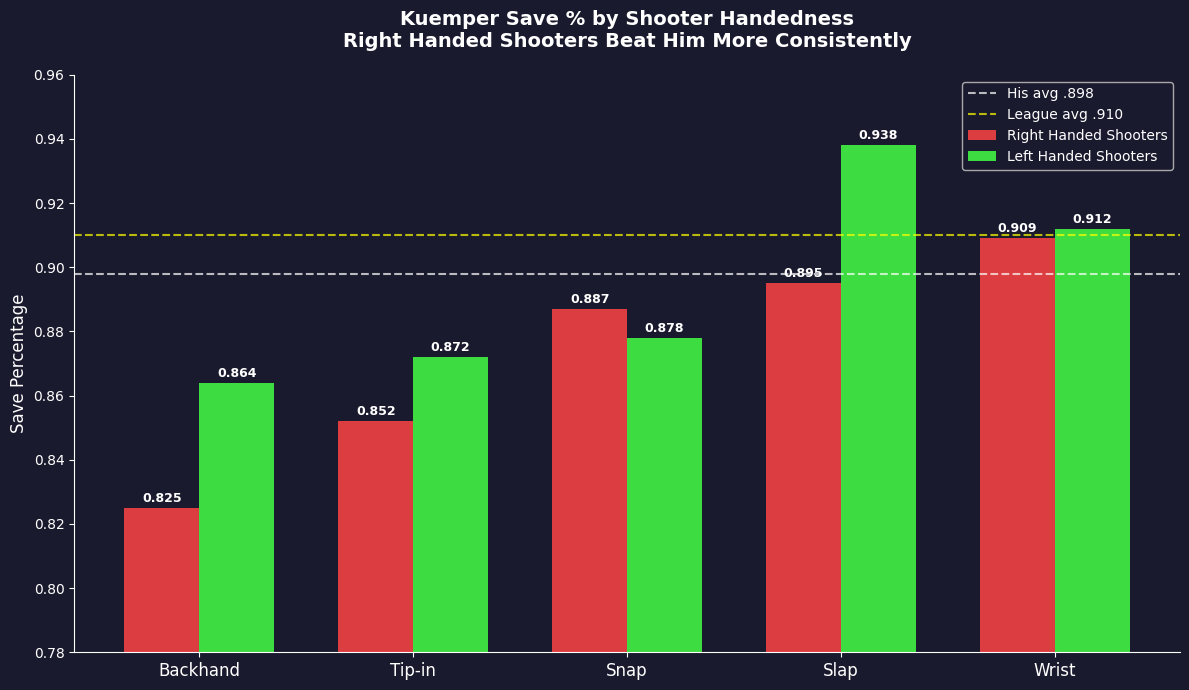

Saved as kuemper_handedness.png


In [29]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

shot_types = ['Backhand', 'Tip-in', 'Snap', 'Slap', 'Wrist']
right_handed = [0.825, 0.852, 0.887, 0.895, 0.909]
left_handed = [0.864, 0.872, 0.878, 0.938, 0.912]

x = np.arange(len(shot_types))
width = 0.35

bars1 = ax.bar(x - width/2, right_handed, width,
               label='Right Handed Shooters',
               color='#ff4444', alpha=0.85)
bars2 = ax.bar(x + width/2, left_handed, width,
               label='Left Handed Shooters',
               color='#44ff44', alpha=0.85)

ax.set_ylim(0.78, 0.96)
ax.axhline(y=0.898, color='white', linestyle='--',
           alpha=0.7, label='His avg .898')
ax.axhline(y=0.910, color='yellow', linestyle='--',
           alpha=0.7, label='League avg .910')

ax.set_xticks(x)
ax.set_xticklabels(shot_types, color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Save Percentage', color='white', fontsize=12)
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=10)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
            f'{height:.3f}', ha='center', va='bottom',
            color='white', fontsize=9, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
            f'{height:.3f}', ha='center', va='bottom',
            color='white', fontsize=9, fontweight='bold')

ax.set_title('Kuemper Save % by Shooter Handedness\nRight Handed Shooters Beat Him More Consistently',
             color='white', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/Users/ashgarg/Library/CloudStorage/OneDrive-Personal/NHL analysis/Goalies/Kuemper/kuemper_handedness.png',
            dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e', edgecolor='none')
plt.show()
print("Saved as kuemper_handedness.png")
